In [6]:
import sys
from pathlib import Path 
import matplotlib.pyplot as plt 
import torch
from PIL import Image
from torchvision import transforms
sys.path.append(str(Path.cwd() / "NST_Code" / "utils"))
from models import VGGEncoder

In [13]:
from pathlib import Path
import torch
from torchvision import transforms

ROOT = Path.cwd()
NST_CODE = ROOT / "NST_Code"

EXAMPLES = NST_CODE / "examples"
VGG_WEIGHTS = NST_CODE / "vgg_normalised.pth"

print("Examples:", EXAMPLES)
print("Weights :", VGG_WEIGHTS)
print("Weights exist:", VGG_WEIGHTS.exists())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_size = 512

image_paths = {
    "Original Brad Pitt": EXAMPLES / "brad_pitt.jpg",
    "Stylized Brad Pitt A": EXAMPLES / "stylized_brad_pitt.jpg",
    "Stylized Brad Pitt B": EXAMPLES / "stylized_brad_pitt (1).jpg",
}

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])

encoder = VGGEncoder(str(VGG_WEIGHTS)).to(device)
encoder.eval()

print("Using device:", device)

Examples: d:\Codes\Projects\NeuralBrush\NST_Code\examples
Weights : d:\Codes\Projects\NeuralBrush\NST_Code\vgg_normalised.pth
Weights exist: True
Using device: cpu


In [15]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.2.2+cpu
CUDA available: False
CUDA version: None
GPU count: 0
Running on CPU


In [23]:
def load_image(path):
    image = Image.open(path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)
    return image, tensor


def show_images (paths_dict):
    fig, axes = plt.subplots(1, len (paths_dict), figsize=(16, 5))
    for ax, (title, path) in zip (axes, paths_dict.items()):
        image = Image.open(path).convert("RGB")
        ax.imshow(image)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()


def extract_features(tensor):
    with torch.no_grad():
        h1, h2, h3, h4 = encoder(tensor)
        return {
            "relu1_1": h1,
            "relu2_1": h2,
            "relu3_1": h3,
            "relu4_1": h4,
        }


def activation_map (feature_tensor):
    activation = feature_tensor[0].mean(dim=0).detach().cpu()
    activation = activation - activation.min()
    activation = activation / (activation.max() + 1e-8)
    return activation

In [24]:
image_tensors = {} 
feature_bank = {}

for name, path in image_paths.items():
    _, tensor = load_image(path)
    image_tensors[name] = tensor
    feature_bank[name] = extract_features(tensor)

for name, features in feature_bank.items():
    shapes = {layer: tuple(feature.shape) for layer, feature in features.items()}
    print (name)
    print(shapes)
    print()

Original Brad Pitt
{'relu1_1': (1, 64, 512, 512), 'relu2_1': (1, 128, 256, 256), 'relu3_1': (1, 256, 128, 128), 'relu4_1': (1, 512, 64, 64)}

Stylized Brad Pitt A
{'relu1_1': (1, 64, 512, 512), 'relu2_1': (1, 128, 256, 256), 'relu3_1': (1, 256, 128, 128), 'relu4_1': (1, 512, 64, 64)}

Stylized Brad Pitt B
{'relu1_1': (1, 64, 512, 512), 'relu2_1': (1, 128, 256, 256), 'relu3_1': (1, 256, 128, 128), 'relu4_1': (1, 512, 64, 64)}



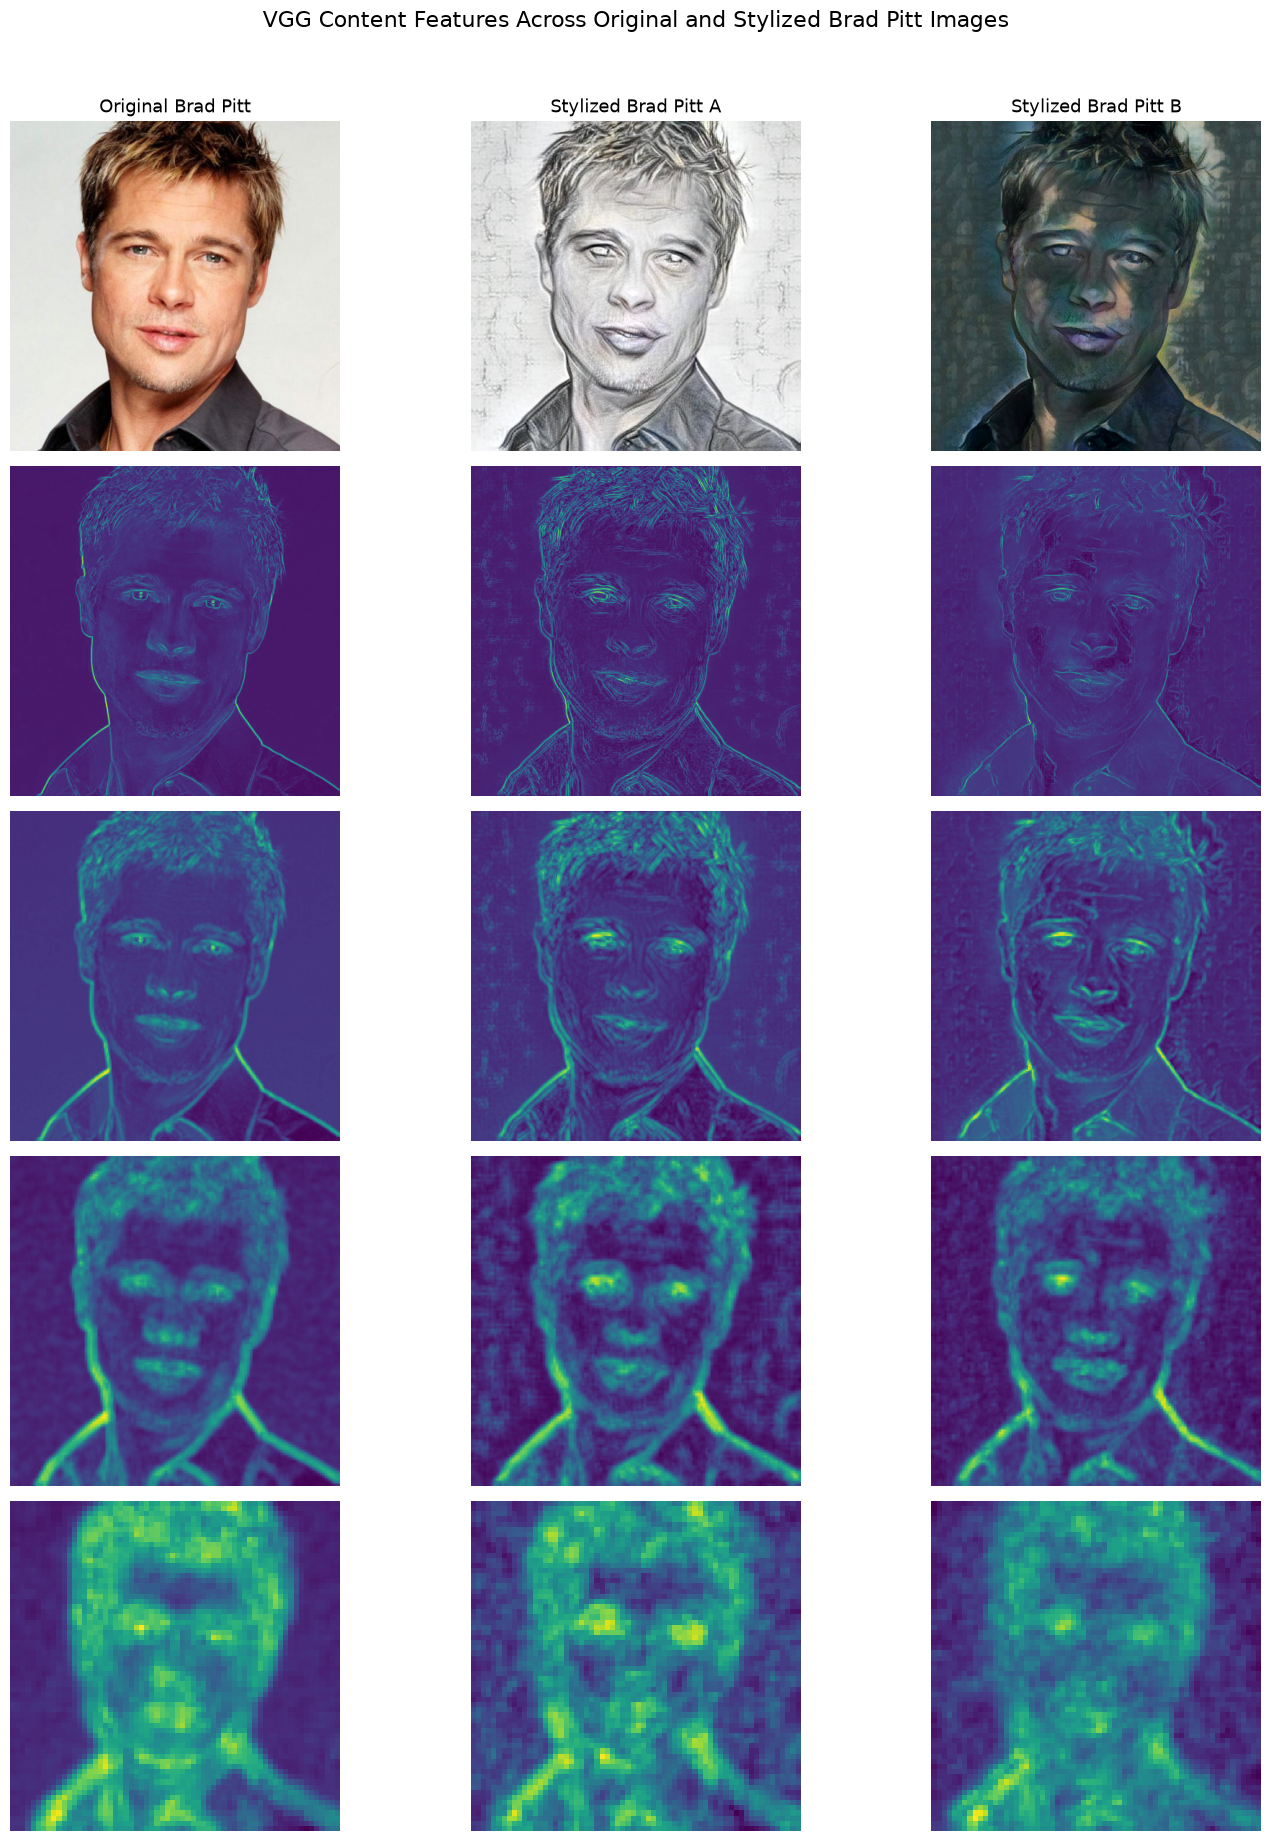

In [25]:
layers_to_show = ["relu1_1", "relu2_1", "relu3_1", "relu4_1"]
row_labels = ["Input Image"] + layers_to_show

num_rows = len(row_labels)
num_cols = len(image_paths)

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(5 * num_cols, 3.6 * num_rows)
)

# Handle the case where there's only one image
if num_cols == 1:
    axes = axes.reshape(num_rows, 1)

for col, (name, path) in enumerate(image_paths.items()):
    # Display input image
    image = Image.open(path).convert("RGB")
    axes[0, col].imshow(image)
    axes[0, col].set_title(name, fontsize=13)
    axes[0, col].axis("off")

    # Display activation maps for each layer
    for row, layer in enumerate(layers_to_show, start=1):
        axes[row, col].imshow(
            activation_map(feature_bank[name][layer]),
            cmap="viridis"
        )
        axes[row, col].axis("off")

# Add row labels
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(
        label,
        fontsize=12,
        rotation=90,
        labelpad=18
    )

plt.suptitle(
    "VGG Content Features Across Original and Stylized Brad Pitt Images",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()